In [1]:

#  PEAK HOUR PREDICTION (Optimized)



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib






In [ ]:

print("📂 Loading dataset...")
df = pd.read_csv(
    r"D:\peak demand electricity\data\household_power_consumption.txt",
    sep=';',
    low_memory=False
)

📂 Loading dataset...


In [3]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0


In [ ]:

df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)
df['Global_active_power'] = df['Global_active_power'].astype(float)



In [ ]:

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df['Hour'] = df['Datetime'].dt.hour

print(f"✅ Data Loaded: {len(df):,} rows")

✅ Data Loaded: 2,049,280 rows


In [ ]:

#  Downsample
df = df.sample(10000, random_state=42)
print("⚡ Using a 10,000-row sample for faster training.")


⚡ Using a 10,000-row sample for faster training.


In [6]:

# Step 4: Aggregate Hourly Averages (better feature quality)
hourly_df = df.groupby('Hour', as_index=False)['Global_active_power'].mean()






In [ ]:
#  Model Training
X = hourly_df[['Hour']]
y = hourly_df['Global_active_power']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = RandomForestRegressor(
    n_estimators=200,     
    max_depth=10,          
    min_samples_split=2,
    random_state=42,
    n_jobs=-1              
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Step 6: Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
accuracy = max(r2 * 100, 0)

print("\n📊 Model Evaluation Metrics:")
print(f"➡️ Mean Absolute Error (MAE): {mae:.4f}")
print(f"➡️ Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"➡️ R² Score: {r2:.4f}")
print(f"✅ Approx. Accuracy: {accuracy:.2f}%")


📊 Model Evaluation Metrics:
➡️ Mean Absolute Error (MAE): 0.1033
➡️ Root Mean Squared Error (RMSE): 0.1165
➡️ R² Score: 0.8374
✅ Approx. Accuracy: 83.74%


In [9]:

# Step 7: Predict Hourly Power
hourly_df['Predicted_Power'] = model.predict(X)


In [10]:

# Step 8: Find Peak & Low Hours
peak_hour = hourly_df.loc[hourly_df['Predicted_Power'].idxmax(), 'Hour']
low_hour = hourly_df.loc[hourly_df['Predicted_Power'].idxmin(), 'Hour']
print(f"\n🔋 Peak Hour: {peak_hour}:00 with {hourly_df['Predicted_Power'].max():.3f} kW")
print(f"💡 Lowest Hour: {low_hour}:00 with {hourly_df['Predicted_Power'].min():.3f} kW")



🔋 Peak Hour: 20:00 with 1.895 kW
💡 Lowest Hour: 4:00 with 0.443 kW


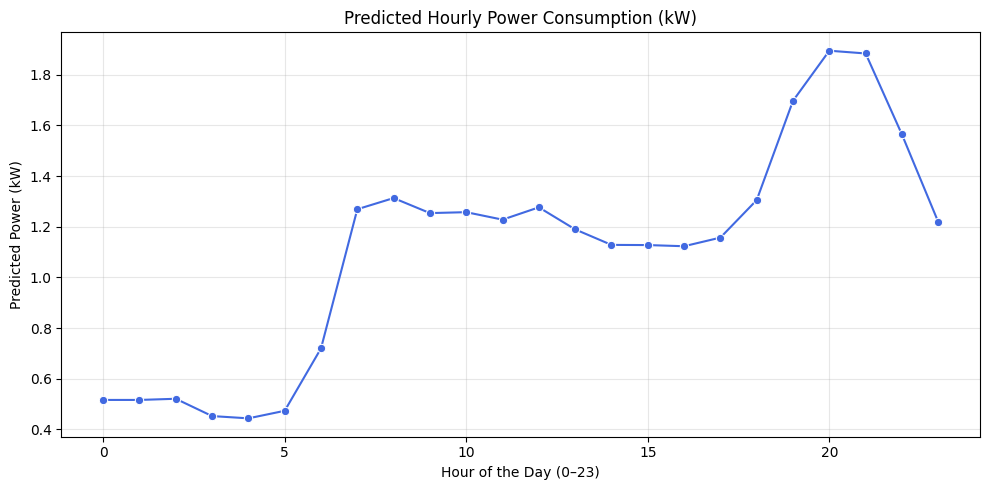

In [11]:

# Step 9: Visualize Predicted Hourly Usage
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_df, x='Hour', y='Predicted_Power', marker='o', color='royalblue')
plt.title("Predicted Hourly Power Consumption (kW)")
plt.xlabel("Hour of the Day (0–23)")
plt.ylabel("Predicted Power (kW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:

# Step 10: Save Model for Streamlit App
joblib.dump(model, "peak_hour_model.pkl")
print("💾 Model saved as 'peak_hour_model.pkl' — ready for use in app.py")


💾 Model saved as 'peak_hour_model.pkl' — ready for use in app.py
